### Iris dataset classification

In this project, we will investigate and process the iris dataset, included in sklearn.datasets, in order to be able to give answers to some ongoing questions about its classification and scores.

### Imports


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [36]:
iris_dataset = load_iris()

X = iris_dataset.data
y = iris_dataset.target
target_names = iris_dataset.target_names
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

a. Use a confusion matrix to evaluate the use of logistic regression to classify the
iris data set

0.9473684210526315


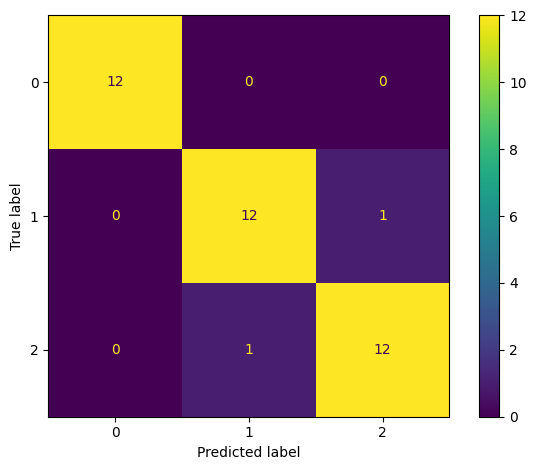

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

logistic_regression = LogisticRegression(random_state=42, max_iter=300)
logistic_regression.fit(X_train , y_train)
y_pred = logistic_regression.predict(X_test)
print(accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, target_names=target_names))

We can conclude that the setosa is predicted correctly, virginica has 3 missclassified and versicolor has 1 missclassified

b. Use k-nearest neighbours to classify the iris data set with some different
values for k, and with uniform and distance-based weights. What will happen
when k grows larger for the different cases? Why?

KNN for k = 1


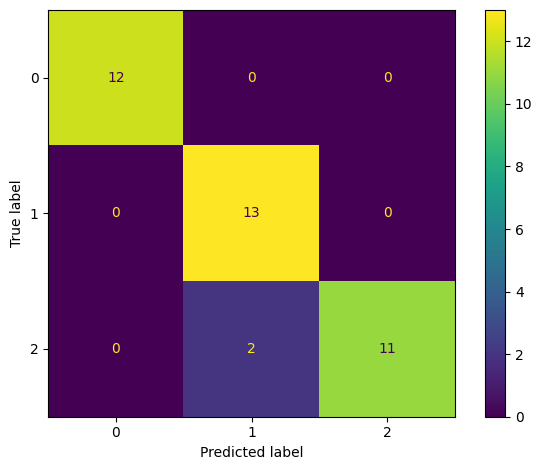

0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

KNN for k = 3


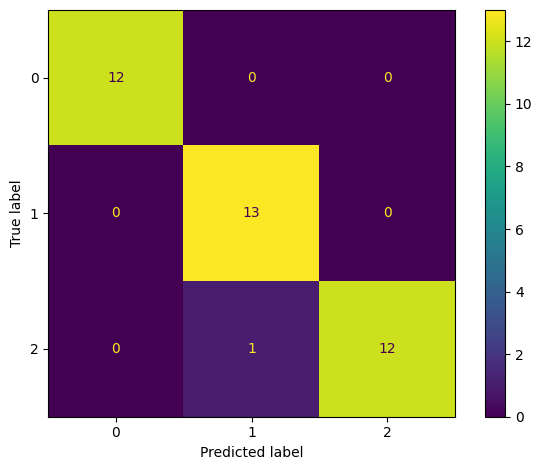

0.9736842105263158
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

KNN for k = 7


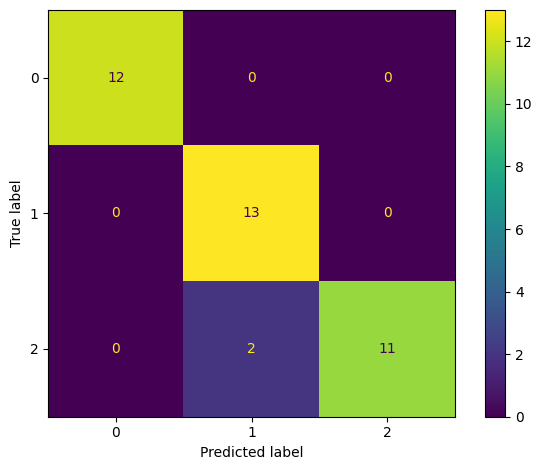

0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

KNN for k = 9


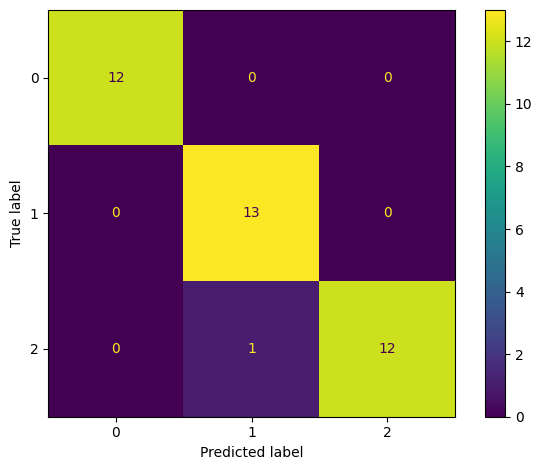

0.9736842105263158
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.93      1.00      0.96        13
   virginica       1.00      0.92      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38

KNN for k = 13


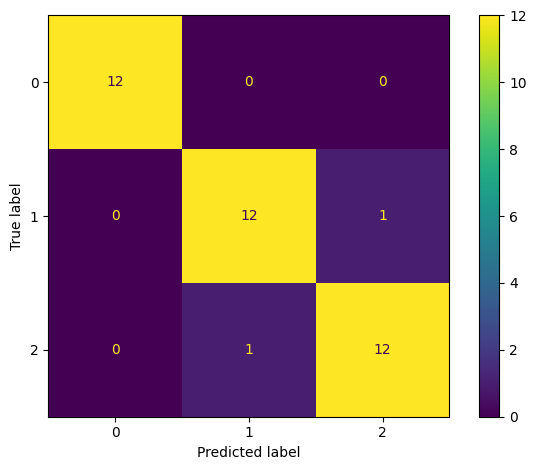

0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38

KNN for k = 21


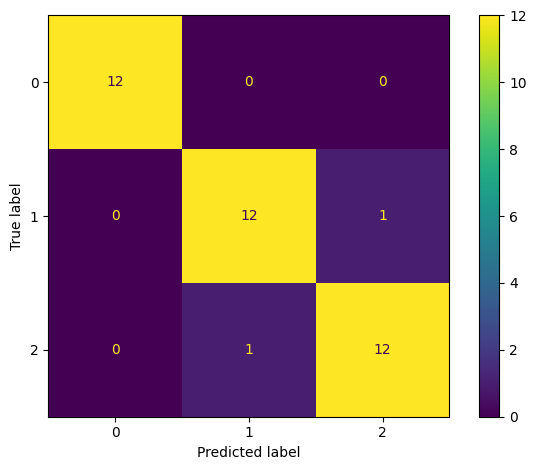

0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



In [35]:
knn_values = [1, 3, 7, 9, 13, 21]

for k in knn_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred_knn = knn.predict(X_test)
    print("KNN for k =", k,)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
    plt.tight_layout()
    plt.show()

    print(accuracy_score(y_test, y_pred_knn))
    print(classification_report(y_test, y_pred_knn, target_names=target_names))

The best result is for k = 9, this is based on the result score and the visible confusion matrices. Larger k values cause over smoothing and lower accuracy.

In conclusion, Both Logistic regression and KNN result in high scores which means that the models are predicting very well.
The only problem with KNN is that for too large k, it causes loss of detail and worse performance.